In [1]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import os
from PIL import Image
from matplotlib.pyplot import GridSpec
import snntorch as snn
from snntorch import surrogate
import snntorch.functional as SF
from snntorch import utils

In [2]:
DATA_DIR = "../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [3]:
from sklearn.preprocessing import LabelEncoder

class CustomDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            return img, label

In [4]:
train_df = pd.read_csv(f"{DATASET_DIR}/train.csv")
test_df = pd.read_csv(f"{DATASET_DIR}/test.csv")
val_df = pd.read_csv(f"{DATASET_DIR}/val.csv")

In [5]:
LE = LabelEncoder()
LE.fit(train_df["Label"].unique())

LE.classes_

# swap classes in the label encoder
swapped_classes = LE.classes_.copy()
swapped_classes[0], swapped_classes[1] = swapped_classes[1], swapped_classes[0]

LE.classes_ = swapped_classes

train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

val_df_encoded = val_df.copy()
val_df_encoded["Label"] = LE.transform(val_df_encoded["Label"])

train_df_encoded.head()

,Image,Label
0,image_1119705.png,1
1,image_2975672.png,1
2,image_6489183.png,1
3,image_2675390.png,1
4,image_5559062.png,1


In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),  # randomly flip images horizontally
    transforms.RandomRotation(10),      # slight random rotation
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # random translation
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))
])


transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))
])

train_dataset = CustomDataset(train_df_encoded, f"{DATASET_DIR}/images", transform=train_transform)
val_dataset = CustomDataset(val_df_encoded, f"{DATASET_DIR}/images", transform=transform)

In [7]:
from torch.utils.data import WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

labels = train_df_encoded["Label"].values
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

In [8]:
sample_weights

array([3. , 3. , 3. , ..., 0.6, 0.6, 0.6])

In [9]:
BATCH_SIZE = 40
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Notes
1. With initial architecture and 4 steps of training, the model achieved 0.93 accuracy on the test set.
2. 3 layer reduced the accuracy to 0.92. reverted back to 4 layers. and using 2nd conv2d output as 64 and no padding instead of 32 and using a transform normalize

In [10]:
class BasicSNN(nn.Module):
    def __init__(self, beta=0.5, num_steps=4, num_classes=2):
        super(BasicSNN, self).__init__()

        self.num_steps = num_steps
        self.num_classes = num_classes
        self.spike_grad = surrogate.fast_sigmoid(slope=25)
        
        self.conv1 = nn.Conv2d(1, 16, kernel_size=4, stride=4)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=2, stride=2)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)

        self.fc1 = nn.Linear(32 * 1 * 1, self.num_classes)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)


    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        spk_rec = []
        mem_rec = []

        for step in range(self.num_steps):
            cur1 = F.max_pool2d(self.conv1(x), 2)  # Remove F.relu
            spike1, mem1 = self.lif1(cur1, mem1)

            cur2 = F.max_pool2d(self.conv2(spike1), 2)  # Remove F.relu
            spike2, mem2 = self.lif2(cur2, mem2)

            # print(spike2.shape)
            flatten = spike2.view(spike2.size(0), -1)

            # print(flatten.shape)
            cur3 = self.fc1(flatten)  # Remove F.relu
            spike3, mem3 = self.lif3(cur3, mem3)

            spk_rec.append(spike3)
            mem_rec.append(mem3)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)
    

For `torch.stack`, the `dim` affects the output of the function.
1. `dim=1` -> shape: `[batch_size, time_step, output_neurons]`
2. `dim=0` -> shape: `[time_step, batch_size, output_neurons]`
3. `dim=-1` -> shape: `[batch_size, output_neurons, time_step]`


In [11]:
dummy = torch.randn(40, 1, 32, 32)
model = BasicSNN()
spk, mem = model(dummy)

spk.shape

torch.Size([4, 40, 2])

In [12]:
def train_model(train_dataloader, val_dataloader, loss_fn, lr=1e-3, weight_decay=None, num_epochs=50, model_savepath=None, device="cuda", dt_ms=1.0):
    # Initialize model
    model = BasicSNN(num_steps=4).to(device)
    
    # Fixed threshold value for now
    try:
        threshold_value = 0.3  # Example threshold value
    except AttributeError:
        print("Warning: Threshold value not found in model. Threshold proximity metrics disabled.")
        threshold_value = None

    # Optimizer
    if weight_decay is not None:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay, betas=(0.9, 0.999))
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    # Tracking lists
    train_loss_hist = []
    val_loss_hist = []    
    avg_train_loss_hist = []
    avg_val_loss_hist = []    
    train_acc_hist = []
    val_acc_hist = []

    # Spike statistics
    spike_stats = {
        'train_avg_spikes_per_neuron': [],
        'train_spike_rate_hz': [],
        'train_spike_count': [],
        'val_avg_spikes_per_neuron': [],
        'val_spike_rate_hz': [],
        'val_spike_count': [],
        'train_active_neurons_percent': [],
        'firing_rate_stability': [],
        'membrane_potential_avg': [],
        'membrane_potential_std': [],
        'threshold_proximity_avg': [],
        'threshold_proximity_std': [],
    }

    best_val_acc = 0
    best_model_state = None
    prev_firing_rates = None  # Track firing rates across epochs

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        model.train()
        epoch_train_loss = 0
        epoch_spike_count = 0
        epoch_active_neurons = 0
        total_neurons = 0
        
        # Membrane potential tracking
        train_sum_mem = 0.0
        train_sum_sq_mem = 0.0
        train_total_mem_samples = 0
        
        # Threshold proximity tracking
        train_proximity_sum = 0.0
        train_proximity_sq_sum = 0.0
        train_proximity_samples = 0

        for data, targets in tqdm(train_dataloader, desc=f"Training"):
            data, targets = data.to(device), targets.to(device)
            
            utils.reset(model)  # Reset neuron states

            # Forward pass
            spk_rec, mem_rec = model(data)  # spk_rec: [time_steps, batch_size, num_neurons]

            # Calculate loss
            loss = loss_fn(spk_rec, targets)
            epoch_train_loss += loss.item()
            train_loss_hist.append(loss.item())

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Spike statistics
            spike_tensor = spk_rec.detach()  # [time_steps, batch_size, num_neurons]
            time_steps = spike_tensor.size(0)
            batch_size = spike_tensor.size(1)
            num_neurons = spike_tensor.size(2)

            # Spike counts
            batch_spike_count = torch.sum(spike_tensor).item()  # Sum over all dimensions
            epoch_spike_count += batch_spike_count

            # Active neurons (neurons that spike at least once)
            active_neurons = torch.sum(torch.sum(spike_tensor, dim=0) > 0).item()  # Sum over time, then count active neurons
            epoch_active_neurons += active_neurons
            total_neurons += batch_size * num_neurons

            # Membrane potential statistics
            if mem_rec is not None:
                mem_tensor = mem_rec.detach()  # [time_steps, batch_size, num_neurons]
                
                # Update membrane sums
                batch_sum_mem = torch.sum(mem_tensor).item()
                batch_sum_sq_mem = torch.sum(mem_tensor**2).item()
                batch_mem_samples = mem_tensor.numel()
                
                train_sum_mem += batch_sum_mem
                train_sum_sq_mem += batch_sum_sq_mem
                train_total_mem_samples += batch_mem_samples

                # Threshold proximity calculations
                if threshold_value is not None:
                    proximity = torch.abs(mem_tensor - threshold_value)
                    train_proximity_sum += torch.sum(proximity).item()
                    train_proximity_sq_sum += torch.sum(proximity**2).item()
                    train_proximity_samples += proximity.numel()

        # Epoch statistics calculation
        avg_train_loss = epoch_train_loss / len(train_dataloader)
        avg_train_loss_hist.append(avg_train_loss)

        # Spike statistics
        avg_spikes_per_neuron = epoch_spike_count / (total_neurons * time_steps)
        avg_spikes_per_neuron_hz = avg_spikes_per_neuron * (1000 / dt_ms)
        active_neurons_percent = (epoch_active_neurons / total_neurons) * 100

        # Membrane potential calculations
        if train_total_mem_samples > 0:
            avg_membrane = train_sum_mem / train_total_mem_samples
            var_membrane = (train_sum_sq_mem / train_total_mem_samples) - (avg_membrane**2)
            std_membrane = np.sqrt(var_membrane) if var_membrane > 0 else 0.0
        else:
            avg_membrane = std_membrane = 0.0

        # Threshold proximity calculations
        if threshold_value is not None and train_proximity_samples > 0:
            avg_proximity = train_proximity_sum / train_proximity_samples
            var_proximity = (train_proximity_sq_sum / train_proximity_samples) - (avg_proximity**2)
            std_proximity = np.sqrt(var_proximity) if var_proximity > 0 else 0.0
        else:
            avg_proximity = std_proximity = 0.0

        # Update spike stats
        spike_stats['train_avg_spikes_per_neuron'].append(avg_spikes_per_neuron)
        spike_stats['train_spike_rate_hz'].append(avg_spikes_per_neuron_hz)
        spike_stats['train_spike_count'].append(epoch_spike_count)
        spike_stats['train_active_neurons_percent'].append(active_neurons_percent)
        spike_stats['membrane_potential_avg'].append(avg_membrane)
        spike_stats['membrane_potential_std'].append(std_membrane)
        spike_stats['threshold_proximity_avg'].append(avg_proximity)
        spike_stats['threshold_proximity_std'].append(std_proximity)

        print(f"Training Loss: {avg_train_loss:.4f}")
        print(f"Avg Spikes/Neuron: {avg_spikes_per_neuron:.4f} ({avg_spikes_per_neuron_hz:.2f}Hz)")
        print(f"Active Neurons: {active_neurons_percent:.2f}%")
        print(f"Membrane Potential: μ={avg_membrane:.2f}±{std_membrane:.2f}")
        if threshold_value is not None:
            print(f"Threshold Proximity: μ={avg_proximity:.2f}±{std_proximity:.2f}")

        # Validation phase
        with torch.no_grad():
            model.eval()
            val_loss = 0
            correct = 0
            total = 0
            val_spike_count = 0
            val_total_neurons = 0
            firing_rates = []
            
            # Membrane tracking for validation
            val_sum_mem = 0.0
            val_sum_sq_mem = 0.0
            val_total_mem_samples = 0
            
            # Threshold proximity for validation
            val_proximity_sum = 0.0
            val_proximity_samples = 0

            for data, targets in tqdm(val_dataloader, desc=f"Validation"):
                data, targets = data.to(device), targets.to(device)
                
                utils.reset(model)

                # Forward pass
                spk_rec, mem_rec = model(data)  # spk_rec: [time_steps, batch_size, num_neurons]

                # Loss and accuracy
                loss = loss_fn(spk_rec, targets)
                acc = SF.accuracy_rate(spk_rec, targets)

                val_loss += loss.item()
                val_loss_hist.append(loss.item())
                correct += acc * data.size(0)
                total += data.size(0)

                # Spike statistics
                spike_tensor = spk_rec.detach()  # [time_steps, batch_size, num_neurons]
                time_steps = spike_tensor.size(0)
                batch_size = spike_tensor.size(1)
                num_neurons = spike_tensor.size(2)

                val_spike_count += torch.sum(spike_tensor).item()
                val_total_neurons += batch_size * num_neurons

                # Firing rates
                batch_firing_rates = torch.mean(spike_tensor, dim=(0, 1)).cpu().numpy()  # Average over time and batch
                firing_rates.append(batch_firing_rates)

                # Membrane potential tracking
                if mem_rec is not None:
                    mem_tensor = mem_rec.detach()  # [time_steps, batch_size, num_neurons]
                    val_sum_mem += torch.sum(mem_tensor).item()
                    val_sum_sq_mem += torch.sum(mem_tensor**2).item()
                    val_total_mem_samples += mem_tensor.numel()

                    # Threshold proximity
                    if threshold_value is not None:
                        proximity = torch.abs(mem_tensor - threshold_value)
                        val_proximity_sum += torch.sum(proximity).item()
                        val_proximity_samples += proximity.numel()

            # Validation statistics
            avg_val_loss = val_loss / len(val_dataloader)
            val_acc = correct / total
            avg_val_loss_hist.append(avg_val_loss)
            val_acc_hist.append(val_acc)

            # Membrane stats
            if val_total_mem_samples > 0:
                avg_val_membrane = val_sum_mem / val_total_mem_samples
                var_val_membrane = (val_sum_sq_mem / val_total_mem_samples) - (avg_val_membrane**2)
                std_val_membrane = np.sqrt(var_val_membrane) if var_val_membrane > 0 else 0.0
            else:
                avg_val_membrane = std_val_membrane = 0.0

            # Validation threshold proximity
            if threshold_value is not None and val_proximity_samples > 0:
                avg_val_proximity = val_proximity_sum / val_proximity_samples
            else:
                avg_val_proximity = 0.0

            # Firing rate stability
            if len(firing_rates) > 0:
                avg_firing_rates = np.atleast_1d(np.concatenate(firing_rates).mean(axis=0))
            else:
                avg_firing_rates = np.array([])

            firing_rate_stability = 0.0

            if prev_firing_rates is not None and isinstance(prev_firing_rates, np.ndarray):
                avg_firing_rates = np.atleast_1d(avg_firing_rates)  # Ensure it's at least 1D
                prev_firing_rates = np.atleast_1d(prev_firing_rates)

                if avg_firing_rates.size > 1 and prev_firing_rates.size > 1:
                    corr_matrix = np.corrcoef(avg_firing_rates, prev_firing_rates)
                    if corr_matrix.shape == (2, 2):  # Verify expected shape
                        corr = corr_matrix[0, 1]
                        firing_rate_stability = 0.0 if np.isnan(corr) else corr

            prev_firing_rates = avg_firing_rates.copy() if avg_firing_rates.size > 0 else None


            spike_stats['firing_rate_stability'].append(firing_rate_stability)

            print(f"Validation Loss: {avg_val_loss:.4f}, Acc: {val_acc:.4f}")
            print(f"Val Spikes/Neuron: {val_spike_count/(val_total_neurons*time_steps):.4f} ({(val_spike_count/(val_total_neurons*time_steps)) * (1000 / dt_ms):.2f}Hz)")
            print(f"Val Membrane: μ={avg_val_membrane:.2f}±{std_val_membrane:.2f}")
            if threshold_value is not None:
                print(f"Val Threshold Proximity: μ={avg_val_proximity:.2f}")
            print(f"Firing Rate Stability: {firing_rate_stability:.4f}")

            # Save best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                # best_model_state = {
                #     'model': model.state_dict(),
                #     'optimizer': optimizer.state_dict(),
                #     'epoch': epoch,
                #     'val_acc': best_val_acc
                # }
                # print(f"New best validation accuracy: {best_val_acc:.4f}")

        # Update learning rate scheduler
        scheduler.step(avg_val_loss)

    # Final model saving
    history = {
        "train_loss": train_loss_hist,
        "val_loss": val_loss_hist,
        "avg_train_loss": avg_train_loss_hist,
        "avg_val_loss": avg_val_loss_hist,
        "val_acc": val_acc_hist,
        "spike_stats": spike_stats,
        "best_val_acc": best_val_acc
    }

    if model_savepath:
        # Save final model
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history
        }, model_savepath)
        print(f"Final model saved at {model_savepath}")

        # Save best model separately
        # if best_model_state is not None:
        #     best_path = model_savepath.replace(".pt", "_best.pt")
        #     torch.save(best_model_state, best_path)
        #     print(f"Best model saved at {best_path} with accuracy {best_val_acc:.4f}")

    return model, history

In [13]:
base_dir = "../models/checkpoints/basic_snn"
model_savepath = f"{base_dir}/modelv2.pt"

os.makedirs(base_dir, exist_ok=True)

In [14]:
savepath = model_savepath

device = "cuda" if torch.cuda.is_available() else "cpu"

# calculate class weights
total_samples = len(train_df_encoded)
class_counts = np.bincount(train_df_encoded["Label"])
class_weights = total_samples / (len(LE.classes_) * class_counts)

class_weights = torch.as_tensor(class_weights, dtype=torch.float32).to(device)

class_weights

tensor([0.6000, 3.0000], device='cuda:0')

In [15]:
loss_fn = SF.ce_rate_loss(weight=class_weights)

In [16]:
model, history = train_model(train_data_loader, val_data_loader, loss_fn, lr=1e-3, weight_decay=None, num_epochs=50, model_savepath=savepath, device=device, dt_ms=1.0)

Epoch 1/50
--------------------------------------------------


Training: 100%|██████████| 750/750 [00:35<00:00, 21.03it/s]


Training Loss: 0.8219
Avg Spikes/Neuron: 0.5238 (523.84Hz)
Active Neurons: 60.16%
Membrane Potential: μ=0.41±1.68
Threshold Proximity: μ=1.52±0.73


Validation: 100%|██████████| 750/750 [00:34<00:00, 21.84it/s]


Validation Loss: 0.4872, Acc: 0.7365
Val Spikes/Neuron: 0.4714 (471.38Hz)
Val Membrane: μ=0.25±1.18
Val Threshold Proximity: μ=0.99
Firing Rate Stability: 0.0000
Epoch 2/50
--------------------------------------------------


...

Validation Loss: 0.4130, Acc: 0.8392
Val Spikes/Neuron: 0.4992 (499.21Hz)
Val Membrane: μ=-0.12±11.54
Val Threshold Proximity: μ=10.24
Firing Rate Stability: 0.0000
Epoch 50/50
--------------------------------------------------


Training: 100%|██████████| 750/750 [00:45<00:00, 16.50it/s]


Training Loss: 0.6218
Avg Spikes/Neuron: 0.4995 (499.52Hz)
Active Neurons: 50.10%
Membrane Potential: μ=-0.06±13.10
Threshold Proximity: μ=11.69±5.93


Validation: 100%|██████████| 750/750 [00:36<00:00, 20.56it/s]


Validation Loss: 0.4130, Acc: 0.8386
Val Spikes/Neuron: 0.4994 (499.39Hz)
Val Membrane: μ=-0.08±11.59
Val Threshold Proximity: μ=10.26
Firing Rate Stability: 0.0000
Final model saved at ../models/checkpoints/basic_snn/modelv2.pt


In [17]:
test_data_encoded = test_df.copy()
test_data_encoded["Label"] = LE.transform(test_data_encoded["Label"])

test_dataset = CustomDataset(test_data_encoded, f"{DATASET_DIR}/images", transform=transform)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [18]:
checkpoint = torch.load(savepath, weights_only=False)
best_model = BasicSNN().to(device)
best_model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [19]:
# sample 10000 data points from test data with equal distribution of benign and malicious samples
test_data_sample = test_data_encoded.groupby("Label").sample(6000, random_state=42)

test_dataset_sample = CustomDataset(test_data_sample, f"{DATASET_DIR}/images", transform=transform)
test_data_loader_sample = DataLoader(test_dataset_sample, batch_size=BATCH_SIZE, shuffle=False)

In [20]:
def calculate_accuracy2(model, test_data_loader_sample, device, class_names=None):
    y_true = torch.tensor([], dtype=torch.long, device=device)
    y_pred = torch.tensor([], dtype=torch.long, device=device)

    with torch.no_grad():
        model.eval()
        correct = 0
        total = 0

        for images, labels in tqdm(test_data_loader_sample, desc="Calculating Accuracy"):
            images, labels = images.to(device), labels.to(device)
            utils.reset(model)  # Reset neuron states per batch

            spk_rec, _ = model(images)  # Shape: [num_steps, batch_size, num_classes]
            spk_mean = spk_rec.mean(dim=0)  # Aggregate spikes over time
            preds = spk_mean.argmax(dim=1)  # Get predictions

            # Append predictions and labels
            y_true = torch.cat((y_true, labels))
            y_pred = torch.cat((y_pred, preds))

            # Compute batch accuracy
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        # Convert to numpy arrays only once
        y_true = y_true.cpu().numpy()
        y_pred = y_pred.cpu().numpy()

        # Compute overall accuracy
        acc = correct / total
        print(f"Accuracy: {acc:.4f}")

    return y_true, y_pred

def calculate_accuracy(model, data_loader, device="cuda"):
    correct = 0
    total = 0

    for data, targets in tqdm(data_loader, desc="Calculating Accuracy"):
        data, targets = data.to(device), targets.to(device)

        utils.reset(model)  # Reset neuron states per batch

        spk_rec, _ = model(data)

        # calculate accuracy
        acc = SF.accuracy_rate(spk_rec, targets)

        correct += acc * data.size(0)
        total += data.size(0)

    return correct / total


y_true, y_pred = calculate_accuracy2(best_model, test_data_loader_sample, device=device)
# Example usage
calculate_accuracy(best_model, test_data_loader_sample, device=device)


Calculating Accuracy: 100%|██████████| 300/300 [00:22<00:00, 13.50it/s]


Accuracy: 0.9551


Calculating Accuracy: 100%|██████████| 300/300 [00:14<00:00, 20.83it/s]


np.float64(0.9550833333333333)

              precision    recall  f1-score   support

   Malicious       0.99      0.92      0.95      6000
      Benign       0.92      0.99      0.96      6000

    accuracy                           0.96     12000
   macro avg       0.96      0.96      0.96     12000
weighted avg       0.96      0.96      0.96     12000



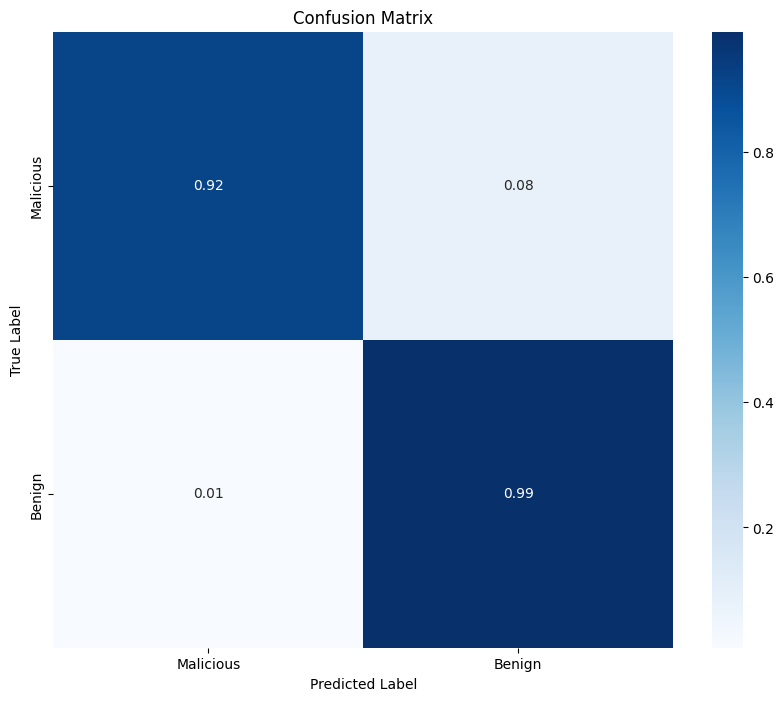

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_cm(y_true, y_pred, classes, normalize=False):
    """Plot confusion matrix."""

    classification_rep = classification_report(y_true, y_pred, target_names=classes)
    print(classification_rep)

    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)), normalize='true' if normalize else None)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


# Plot confusion matrix
plot_cm(y_true, y_pred, LE.classes_, normalize=True)